# Classificação de Documentos Jurídicos

## Importação de Bibliotecas e Configurações

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)

## Carregamento dos Dados

In [3]:
PATH = './dataset/'
train_df = pd.read_csv(PATH + 'train.csv')
test_df = pd.read_csv(PATH + 'test.csv')

print(f"Formato da base de Treino: {train_df.shape}")
print(f"Formato da base de Teste: {test_df.shape}")
train_df.head(5)

Formato da base de Treino: (18370, 49)
Formato da base de Teste: (2042, 48)


,Id,Category,Body,text_clean,text_head_30,word_count,char_count,unique_words,lexical_diversity,avg_word_len,...,kw_embargo,kw_jurisprudencia,kw_sumula,kw_merito,kw_admissibilidade,kw_fundamentacao,count_recurso,count_decisao,count_sentenca,count_artigo_kw
0,14731,4,"{""que do reajustamento dos benefÃ­cios prestaÃ§Ã£o continuada previdÃªncia social parÃ¡grafo Ãºnico renumerado pela LEI_8620 grifei ARTIGO_28 entende por salÃ¡rio contribuiÃ§Ã£o o limite mÃ¡ximo s...",que do reajustamento dos benefícios prestação continuada previdência social parágrafo único renumerado pela LEI_8620 grifei ARTIGO_28 entende por salário contribuição o limite máximo salário contr...,que do reajustamento dos benefícios prestação continuada previdência social parágrafo único renumerado pela LEI_8620 grifei ARTIGO_28 entende por salário contribuição o limite máximo salário contr...,334,2617,192,0.5731,6.838,...,0,1,1,0,0,0,0,0,0,0
1,2740,3,"{""___________________________________________ a princÃ­pio paridade isonomia incorporaÃ§Ã£o gratificaÃ§Ã£o desempenho nos proventos aposentadoria dos inativos abrangidos pelos ars e a ec ARTIGO_3 ...",___________________________________________ a princípio paridade isonomia incorporação gratificação desempenho nos proventos aposentadoria dos inativos abrangidos pelos ars e a ec ARTIGO_3 consoan...,___________________________________________ a princípio paridade isonomia incorporação gratificação desempenho nos proventos aposentadoria dos inativos abrangidos pelos ars e a ec ARTIGO_3 consoan...,165,1375,112,0.6747,7.339,...,0,0,0,0,0,0,0,0,0,0
2,23559,4,"{""Ã© com esses fundamentos pois que rejeito pretensÃ£o repetiÃ§Ã£o indÃ©bito dano moral apontada nos fundamentos acima inexistÃªncia dÃ©bito autor para com rÃ©u resta exame reparaÃ§Ã£o moral reque...",é com esses fundamentos pois que rejeito pretensão repetição indébito dano moral apontada nos fundamentos acima inexistência débito autor para com réu resta exame reparação moral requerida segundo...,é com esses fundamentos pois que rejeito pretensão repetição indébito dano moral apontada nos fundamentos acima inexistência débito autor para com réu resta exame reparação moral requerida segundo...,510,3663,317,0.6204,6.184,...,0,1,0,0,0,0,1,2,0,0
3,17128,1,"{""para obrigaÃ§Ã£o fazer acima fixada estipulo prazo para cumpr imento sob pena multa diÃ¡ria valor r contar ciÃªncia descumprimento obrigaÃ§Ã£o fazer parte autora terÃ¡ prazo dias para noticiar j...",para obrigação fazer acima fixada estipulo prazo para cumpr imento sob pena multa diária valor r contar ciência descumprimento obrigação fazer parte autora terá prazo dias para noticiar juízo sob ...,para obrigação fazer acima fixada estipulo prazo para cumpr imento sob pena multa diária valor r contar ciência descumprimento obrigação fazer parte autora terá prazo dias para noticiar juízo sob,164,1208,135,0.8182,6.372,...,0,0,1,0,0,0,2,3,2,0
4,6743,3,"{""advocacia geral uniÃ£o procuradoria uniÃ£o paraÃ­ba alÃ©m disso conforme exposto nÃ£o que falar inconstitucionalidade LEI_11357 presumidamente constitucional finalmente cumpre relembrar que pacÃ...",advocacia geral união procuradoria união paraíba além disso conforme exposto não que falar inconstitucionalidade LEI_11357 presumidamente constitucional finalmente cumpre relembrar que pacífico ju...,advocacia geral união procuradoria união paraíba além disso conforme exposto não que falar inconstitucionalidade LEI_11357 presumidamente constitucional finalmente cumpre relembrar que pacífico ju...,290,2227,210,0.7216,6.683,...,0,1,1,0,0,0,0,4,0,0


## Análise Exploratória (EDA)

Coluna de ID: Id
Coluna do Texto: text_clean
Coluna Alvo (Target): Category

--- Valores Faltantes ---
text_clean    4
Category      0
dtype: int64


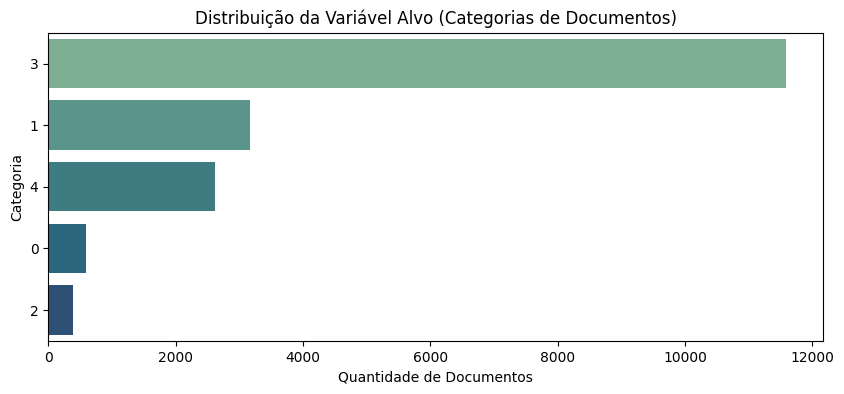

In [4]:
id_col = 'id' if 'id' in train_df.columns else train_df.columns[0]
text_col = [c for c in train_df.columns if 'text' in c.lower() or 'doc' in c.lower() or 'conteudo' in c.lower() or 'peticao' in c.lower()][0]
target_col = [c for c in train_df.columns if c not in [id_col, text_col]][0]

print(f"Coluna de ID: {id_col}")
print(f"Coluna do Texto: {text_col}")
print(f"Coluna Alvo (Target): {target_col}")

print("\n--- Valores Faltantes ---")
print(train_df[[text_col, target_col]].isnull().sum())

plt.figure(figsize=(10, 4))
sns.countplot(data=train_df, y=target_col, order=train_df[target_col].value_counts().index, palette='crest')
plt.title('Distribuição da Variável Alvo (Categorias de Documentos)')
plt.xlabel('Quantidade de Documentos')
plt.ylabel('Categoria')
plt.show()

## Limpeza e Pré-processamento

Textos jurídicos contêm numerações de processos, citações e caracteres especiais. Aplicamos uma limpeza direcionada para remover ruídos numéricos e de pontuação mantendo a integridade de jargões técnicos (*jurisprudência*, *deferimento*, *agravo*).

In [5]:
def preprocess_legal_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    # Remover números de processos (ex: 0001234-88.2020.8.26.0000)
    text = re.sub(r'\d{7}-\d{2}\.\d{4}\.\d\.\d{2}\.\d{4}', ' ', text)
    
    # Remover números isolados e caracteres especiais excessivos
    text = re.sub(r'\d+', ' ', text)
    
    # Remover pontuações e símbolos de formatação jurídica
    text = text.translate(str.maketrans('', '', string.punctuation + 'ºª§'))
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("Aplicando pré-processamento nos textos de treino e teste...")
train_df['clean_text'] = train_df[text_col].apply(preprocess_legal_text)
test_df['clean_text'] = test_df[text_col].apply(preprocess_legal_text)

print("\n--- Exemplo de Texto Limpo ---")
print(train_df['clean_text'].iloc[0][:300] + "...")

Aplicando pré-processamento nos textos de treino e teste...

--- Exemplo de Texto Limpo ---
que do reajustamento dos benefícios prestação continuada previdência social parágrafo único renumerado pela lei grifei artigo entende por salário contribuição o limite máximo salário contribuição de cento setenta mil cruzeiros reajustado partir data entrada vigor desta lei mesma época com mesmos índ...


## Vetorização e Extração de Features

Utilizamos **TF-IDF (Term Frequency-Inverse Document Frequency)** com unigramas e bigramas (`ngram_range=(1, 2)`). O uso de `sublinear_tf=True` mitiga o impacto desproporcional do tamanho do documento sobre termos muito repetidos.

In [6]:
le = LabelEncoder()
y = le.fit_transform(train_df[target_col].astype(str))
class_names = le.classes_
num_classes = len(class_names)

print(f"Total de classes ({num_classes}): {list(class_names)}")

vectorizer = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

print("Vetorizando os textos com TF-IDF...")
X = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

print(f"Formato da matriz TF-IDF (Treino): {X.shape}")
print(f"Formato da matriz TF-IDF (Teste): {X_test.shape}")

Total de classes (5): ['0', '1', '2', '3', '4']
Vetorizando os textos com TF-IDF...
Formato da matriz TF-IDF (Treino): (18370, 25000)
Formato da matriz TF-IDF (Teste): (2042, 25000)


## Validação Cruzada Estratificada e Treinamento (Stratified K-Fold)

Usamos o **Stratified K-Fold (5 Folds)** com **Regressão Logística Multiclasse** (`class_weight='balanced'`) para tratar o desbalanceamento inerente entre os tipos de petições/documentos.

In [7]:
SEED = 42
np.random.seed(SEED)

FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros((X.shape[0], num_classes))
test_preds = np.zeros((X_test.shape[0], num_classes))
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    
    model = LogisticRegression(C=2.0, max_iter=1000, class_weight='balanced', random_state=SEED, n_jobs=-1)
    model.fit(X_train, y_train)
    
    val_probs = model.predict_proba(X_val)
    oof_preds[val_idx] = val_probs
    
    val_pred_labels = np.argmax(val_probs, axis=1)
    fold_f1 = f1_score(y_val, val_pred_labels, average='macro')
    f1_scores.append(fold_f1)
    
    print(f"Fold {fold + 1} - F1-Score Macro: {fold_f1:.4f}")
    
    test_preds += model.predict_proba(X_test) / FOLDS

oof_labels = np.argmax(oof_preds, axis=1)
overall_f1_macro = f1_score(y, oof_labels, average='macro')
overall_f1_weighted = f1_score(y, oof_labels, average='weighted')

print(f"Média F1-Score Macro nos {FOLDS} Folds: {np.mean(f1_scores):.4f}")
print(f"OOF Overall F1-Score (Macro):    {overall_f1_macro:.4f}")
print(f"OOF Overall F1-Score (Weighted): {overall_f1_weighted:.4f}")

Fold 1 - F1-Score Macro: 0.8867
Fold 2 - F1-Score Macro: 0.8839
Fold 3 - F1-Score Macro: 0.8897
Fold 4 - F1-Score Macro: 0.8788
Fold 5 - F1-Score Macro: 0.8772
Média F1-Score Macro nos 5 Folds: 0.8833
OOF Overall F1-Score (Macro):    0.8832
OOF Overall F1-Score (Weighted): 0.8955


## Avaliação de Resultados & Matriz de Confusão

=== RELATÓRIO DE CLASSIFICAÇÃO (Out-Of-Fold) ===
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       598
           1       0.71      0.87      0.78      3176
           2       0.93      0.90      0.92       395
           3       0.96      0.88      0.92     11588
           4       0.90      0.96      0.93      2613

    accuracy                           0.89     18370
   macro avg       0.87      0.91      0.88     18370
weighted avg       0.90      0.89      0.90     18370



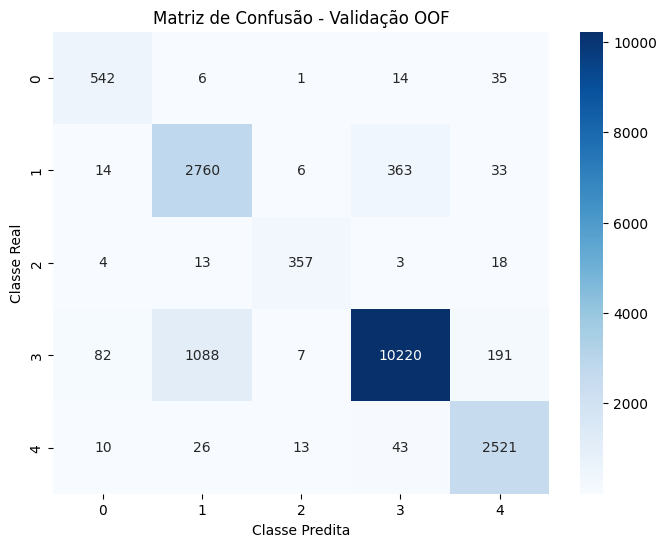

In [8]:
print("=== RELATÓRIO DE CLASSIFICAÇÃO (Out-Of-Fold) ===")
print(classification_report(y, oof_labels, target_names=[str(c) for c in class_names]))

cm = confusion_matrix(y, oof_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão - Validação OOF')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.show()

## Geração do Arquivo de Submissão

In [9]:
final_pred_indices = np.argmax(test_preds, axis=1)
final_pred_labels = le.inverse_transform(final_pred_indices)

submission = pd.DataFrame({
    id_col: test_df[id_col],
    target_col: final_pred_labels
})


submission.to_csv('submission.csv', index=False)
print("✅ Arquivo 'submission.csv' gerado com sucesso!")
submission.head(10)

✅ Arquivo 'submission.csv' gerado com sucesso!


,Id,Category
0,21873,4
1,111,3
2,17895,1
3,21006,3
4,4710,4
5,23839,0
6,14718,3
7,17663,3
8,386,3
9,18787,3
